# AGU24 Material

Material for AGU24, for the parts of my analysis where I use Python 

In [2]:
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr

import os
from pathlib import Path
import numpy as np
import pandas as pd
import dask
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
import math

import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

from matplotlib import animation
from IPython.display import Video
from matplotlib.cm import prism

from ipywidgets import IntProgress
from IPython.display import display

repo_dir = str(Path(os.getcwd()).parents[0])
os.chdir(repo_dir + '/scripts/')
from utils import display_catalog
from st_dbscan import ST_DBSCAN

Choosing all storms which make landfall over the AIS, and also spend at least some time over the Southern Ocean as well.

# Data: Building an AR Catalog

In [3]:
# Load up the AR catalogs
curwd = os.getcwd()
catalog_paths = str(Path(curwd).parents[0]) + '/data/ar_catalogs/*.nc'
full_catalog = xr.open_mfdataset(catalog_paths)

In [10]:
full_catalog.lon

<xarray.DataArray 'lon' (lon: 576)> Size: 5kB
array([-180.   , -179.375, -178.75 , ...,  178.125,  178.75 ,  179.375])
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
Attributes:
    standard_name:  longitude
    long_name:      Longitude
    units:          degrees_east
    axis:           X

In [17]:
# grab time slice
catalog_slice = full_catalog.isel(time=310).ar_binary_tag.sel(lat=slice(-86, -39))

colormap = matplotlib.colors.ListedColormap(['mediumvioletred'])
levels = np.array([0.5,1.5]) # levels for the colormap 

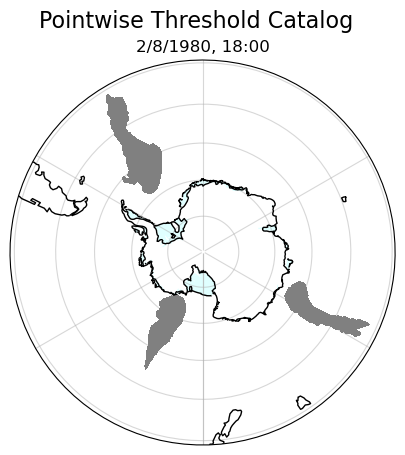

In [19]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
ax.contourf(catalog_slice.lon, catalog_slice.lat, catalog_slice, levels=levels, colors='gray', transform=ccrs.PlateCarree(), zorder=31)
ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
#land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
#ax.add_feature(land_50m,linewidth=3)
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
ax.gridlines(alpha=0.5, zorder=33)
time_ts = pd.Timestamp(catalog_slice.time.values)
ax.set_title(f'{time_ts.month}/{time_ts.day}/{time_ts.year}, {time_ts.hour}:00')
fig.suptitle('Pointwise Threshold Catalog', fontsize=16);
plt.savefig(repo_dir + '/plots/agu_plots/wille_raw_catalog.png', dpi=300)

In [20]:
# Load up the AR catalogs
curwd = os.getcwd()
catalog_paths = str(Path(curwd).parents[0]) + '/data/ar_catalogs/*.nc'
full_catalog = xr.open_mfdataset(catalog_paths)

# Load up the AIS mask
mask_path = str(Path(curwd).parents[0]) + '/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc'
full_ais_mask = xr.open_dataset(mask_path).Zwallybasins > 0

catalog = full_catalog.sel(lat=slice(-86, -39))
ais_mask = full_ais_mask.sel(lat=slice(-86, -39))

# subset for a year just to showcase the algorithm
start_date = '1980-02-01T03:00:00.000000000'
end_date = '1980-02-15T03:00:00.000000000'
practice_catalog = catalog.sel(time=slice(start_date, end_date))
# get rid of all time steps for which there is no AR present
is_ar_time = practice_catalog.ar_binary_tag.any(dim = ['lat', 'lon'])
practice_catalog = practice_catalog.sel(time=is_ar_time).ar_binary_tag

In [21]:
# clustering hyperparams

synoptic_scale = (10**3)/2
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian  
eps_space = synoptic_scale/km_per_radian
eps_time = 18/24
minpts = 5

n_rep_pts = 10

In [22]:
clust_obj = ST_DBSCAN(eps_space, eps_space, eps_time, minpts, minpts, n_rep_pts)
obj = clust_obj.fit(practice_catalog)

cluster_infos_df = obj
cluster_infos_df = cluster_infos_df[cluster_infos_df['cluster'] != -1]

plt_df = cluster_infos_df



Beginning spatial clustering step.


100%|██████████| 57/57 [00:10<00:00,  5.42it/s]
/global/u1/j/jbbutler/extreme_antarctic_ARs/scripts/st_dbscan.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.


In [24]:
unique_clusters = plt_df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism((j+50)/100) for j in range(len(unique_clusters)) }

times = np.array(pd.date_range('1980-02-06T03:00:00.000000000', '1980-02-10T03:00:00.000000000', freq='3h'))

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
128    13.0
129    14.0
130    14.0
131    14.0
132    14.0
Name: cluster, Length: 132, dtype: float64

In [33]:
def plt_time(time_pt):

    if (time_pt == plt_df.time).any():
        dat = plt_df[plt_df['time'] == time_pt]
        n_clusts = dat.shape[0]

        for i in range(n_clusts):
            cluster = int(dat['cluster'].iloc[i])
            ax.scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
            ax.annotate(text=f'AR {cluster}', xy=(dat['mean_lon'].iloc[i], dat['mean_lat'].iloc[i]), fontsize=18, transform=ccrs.PlateCarree(), color='red', zorder=35)
        
        #ax.legend()

    #if (time_pt == practice_catalog.time).any():
        # grab time slice from Jonathan's raw AR catalogs
    #    catalog_slice = practice_catalog.sel(time=time_pt)
    #    ax.contour(catalog_slice.lon, catalog_slice.lat, catalog_slice, transform=ccrs.PlateCarree(), zorder=31, linestyles='dotted', colors='black', linewidths=1)
    
    ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    #land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
    #ax.add_feature(land_50m,linewidth=3)
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax.coastlines(resolution='110m',linewidth=1,zorder=32)
    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time_pt)
    ax.set_title(f'{time_ts.month}/{time_ts.day}/{time_ts.year}, {time_ts.hour}:00')

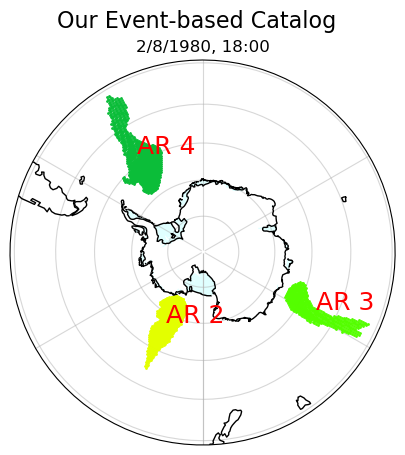

In [37]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
plt_time(catalog_slice.time.values)
fig.suptitle('Our Event-based Catalog', fontsize=16);
plt.savefig(repo_dir + '/plots/agu_plots/identified_storms.png', dpi=300)

In [88]:
# load up all of the dataframes by year, and then concatenate into one big one
df_path = repo_dir + '/data/ar_database/dataframes/'
fnames = os.listdir(df_path)
df_list = []

for fname in fnames:
    df_list.append(pd.read_hdf(df_path + fname))
    
storms = pd.concat(df_list)

In [89]:
def compute_duration(ar_da):
    days = (ar_da.time.max() - ar_da.time.min()).values.astype('timedelta64[h]').astype(int) + np.timedelta64(3, 'h')
    return days

def add_start_date(ar_da):
    start = ar_da.time.min().values
    return start

def add_end_date(ar_da):
    end = ar_da.time.max().values
    return end

In [90]:
storms['duration'] = storms['data_array'].apply(compute_duration)
storms['start_date'] = storms['data_array'].apply(add_start_date)
storms['end_date'] = storms['data_array'].apply(add_end_date)

,data_array,is_landfalling,duration,start_date,end_date
cluster,,,,,
26,,False,2 days 00:00:00,1980-02-06 21:00:00,1980-02-08 18:00:00
27,,True,2 days 15:00:00,1980-02-07 18:00:00,1980-02-10 06:00:00
28,,False,2 days 06:00:00,1980-02-08 00:00:00,1980-02-10 03:00:00

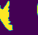
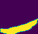

In [103]:
plotted_storms = storms.loc[26:28]
display_catalog(plotted_storms)

,data_array
2,
3,
4,

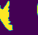
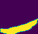

In [107]:
display_catalog(plotted_storms.set_index(pd.Index([2,3,4]))[['data_array']])

In [108]:
# loading up the catalog
catalog = pd.read_hdf('~/extreme_antarctic_ARs/data/landfalling_storm_quantities_df.h5')
catalog = catalog[catalog.landfalling_SLP < 10**7]

In [129]:
catalog_subset = catalog.sort_index()[['max_IWV_ais', 'max_T2M_anomaly_ais', 'cumulative_snowfall_ais']]
catalog_subset['cumulative_snowfall_ais'] = round(catalog_subset['cumulative_snowfall_ais']/10**13,3)
catalog_subset['max_T2M_anomaly_ais'] = round(catalog_subset['max_T2M_anomaly_ais'], 2)
catalog_subset['max_IWV_ais'] = round(catalog_subset['max_IWV_ais'], 2)

In [132]:
catalog_subset.loc[1:20].rename(columns={'max_IWV_ais':'IWV', 'max_T2M_anomaly_ais':'T Anomaly', 'cumulative_snowfall_ais':'Snowfall'})

,IWV,T Anomaly,Snowfall
cluster,,,
1.0,19.39,4.73,0.048
3.0,15.27,9.10,0.622
11.0,9.88,4.73,0.107
12.0,12.22,8.24,0.272
13.0,16.23,12.36,1.411
14.0,9.08,3.04,0.007
15.0,16.23,8.48,0.238


,data_array,cumulative_landfalling_area,max_T2M_anomaly_ais,cumulative_snowfall_ais
cluster,,,,
1,,26690.252548,4.733398,479409079224.786621
3,,332707.755748,9.100540,6217643706322.639648
11,,52690.776358,4.731720,1066740012230.389404
12,,149735.533721,8.239502,2718184777635.166992
13,,1604992.830575,12.359955,14106844446652.851562
14,,857.525114,3.037811,69093967650.605286
15,,532885.909276,8.477936,2377427010143.406250
27,,541622.498910,11.695755,7558993216841.231445
29,,10747.127920,7.388245,348645865489.240356

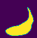
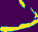
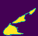
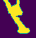
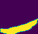
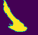

In [113]:
display_catalog(, 10)

In [ ]:
catalog